c:\Users\Alicja\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


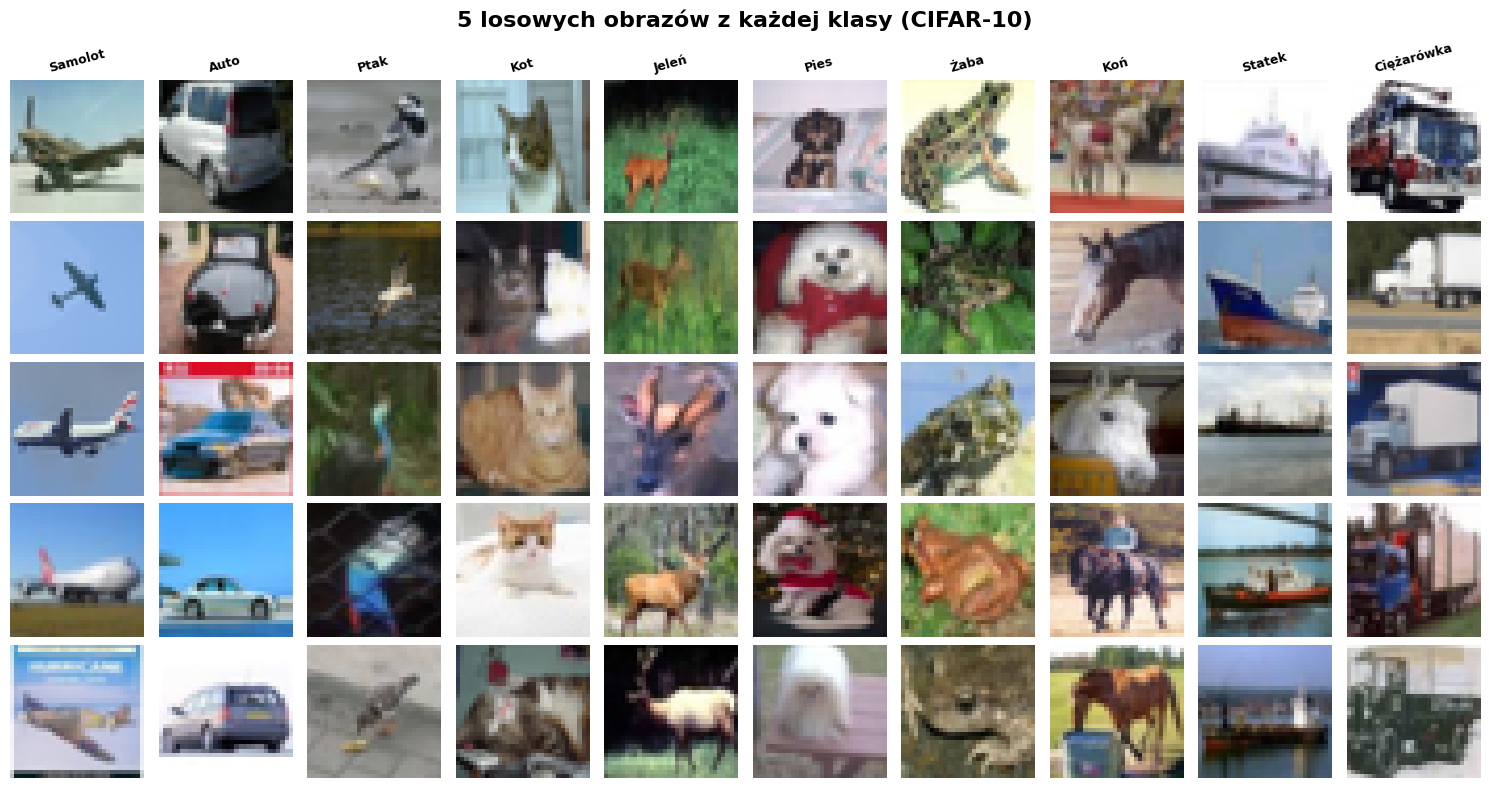

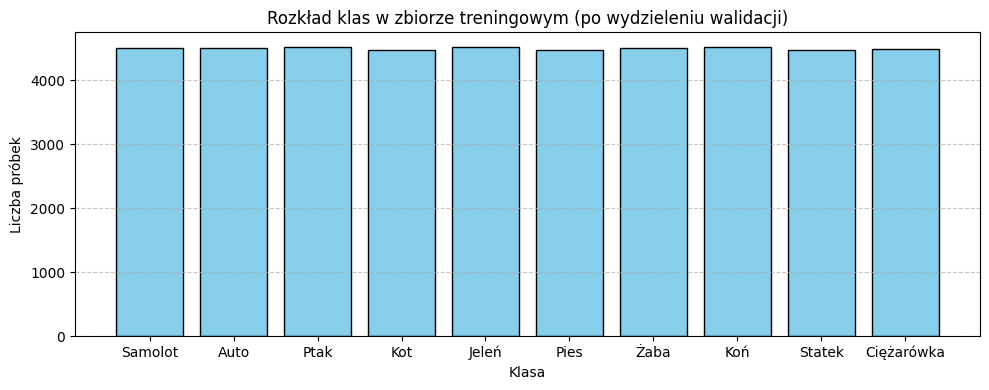

PODSTAWOWE STATYSTYKI KANAŁÓW (dla wartości 0.0 - 1.0):
Czerwony (R)    -> Średnia: 0.4915 | Odchylenie std: 0.2472
Zielony (G)     -> Średnia: 0.4821 | Odchylenie std: 0.2437
Niebieski (B)   -> Średnia: 0.4464 | Odchylenie std: 0.2617
------------------------------------------------------------


In [2]:
# Wczytaj CIFAR10, wyświetl 5 losowych obrazów z każdej klasy 510 siatka), pokaż rozkład klas i
# podstawowe statystyki.
# Dataset: keras.datasets.cifar10
# Wymagania:
# Siatka 510 5 obrazów per klasa)
# Rozkład klas (histogram)
# Średnia i std pikseli per kanał R, G, B

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# Dane CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()

# Podział train/val
x_val = x_train[-5000:]
y_val = y_train[-5000:]
x_train = x_train[:-5000]
y_train = y_train[:-5000]

class_name = ['Samolot', 'Auto', 'Ptak', 'Kot', 'Jeleń', 'Pies', 'Żaba', 'Koń', 'Statek', 'Ciężarówka']

num_classes = 10
images_per_class = 5

fig, axes = plt.subplots(images_per_class, num_classes, figsize=(15, 8))
fig.suptitle("5 losowych obrazów z każdej klasy (CIFAR-10)", fontsize=16, fontweight='bold')

for class_idx in range(num_classes):
    # Znajdujemy indeksy obrazów dla danej klasy
    indices = np.where(y_train == class_idx)[0]
    # Losujemy 5 unikalnych indeksów
    random_indices = np.random.choice(indices, images_per_class, replace=False)
    
    for row_idx, img_idx in enumerate(random_indices):
        ax = axes[row_idx, class_idx]
        ax.imshow(x_train[img_idx])
        ax.axis("off")
        
        # Nazwa klasy tylko nad pierwszym wierszem kolumny
        if row_idx == 0:
            ax.set_title(class_name[class_idx], fontsize=9, fontweight='bold', rotation=15)

plt.tight_layout()
plt.show()

# Rozkład klas (histogram)
plt.figure(figsize=(10, 4))
counts = np.bincount(y_train)
plt.bar(class_name, counts, color="skyblue", edgecolor="black")
plt.title("Rozkład klas w zbiorze treningowym (po wydzieleniu walidacji)")
plt.xlabel("Klasa")
plt.ylabel("Liczba próbek")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

#Średnia i std pikseli per kanał R, G, B
means = np.mean(x_train, axis=(0, 1, 2))
stds = np.std(x_train, axis=(0, 1, 2))

print("PODSTAWOWE STATYSTYKI KANAŁÓW (dla wartości 0.0 - 1.0):")

channels = ["Czerwony (R)", "Zielony (G)", "Niebieski (B)"]
for i, channel in enumerate(channels):
    print(f"{channel:15} -> Średnia: {means[i]:.4f} | Odchylenie std: {stds[i]:.4f}")
print("-" * 60)

In [1]:
# Zbuduj najprostszą CNN 2 bloki Conv+Pool) na CIFAR10 BEZ augmentacji i regularyzacji. Wytrenuj 15 epok.
# Jaka accuracy?
# Dataset: keras.datasets.cifar10
# Wymagania:
# 2 bloki Conv2D  MaxPool
# Bez augmentacji, BN, Dropout
# Test accuracy po 15 epokach

import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

# Dane CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()

# Podział train/val
x_val = x_train[-5000:]
y_val = y_train[-5000:]
x_train = x_train[:-5000]
y_train = y_train[:-5000]

# Augmentacja jako warstwy
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

def build_cnn(use_augmentation=False):
    """Buduje model CNN z lub bez augmentacji."""
    model_layers = []
    model_layers.append(layers.Input(shape=(32, 32, 3)))
    
    if use_augmentation:
        model_layers.append(data_augmentation)
        
    # Blok 1
    model_layers.extend([
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
    ])
    
    # Blok 2
    model_layers.extend([
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),

_IncompleteInputError: incomplete input (2502840328.py, line 51)